In [87]:
#Importation des bibliotheques
import numpy as np
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.svm import SVC 
from sklearn import datasets 
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.preprocessing import StandardScaler
import seaborn as sns


In [88]:
#Chargement du dataset iris
iris=datasets.load_iris()
X=pd.DataFrame(iris.data,columns=iris.feature_names)
Y=pd.Series(iris.target,name="classe")
X.head(),Y.head()


(   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
 0                5.1               3.5                1.4               0.2
 1                4.9               3.0                1.4               0.2
 2                4.7               3.2                1.3               0.2
 3                4.6               3.1                1.5               0.2
 4                5.0               3.6                1.4               0.2,
 0    0
 1    0
 2    0
 3    0
 4    0
 Name: classe, dtype: int64)

In [89]:
#Separation train/test
(X_train,X_test,Y_train,Y_test)=train_test_split(X,Y,test_size=0.2,random_state=42)
#Normalisation des données
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)


In [90]:
#Entrainement du modele SVC lineaire 
svm_linear=SVC(kernel="linear")
svm_linear.fit(X_train_scaled,Y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [91]:
#Entrainement du modele SVC polynomial
svm_poly=SVC(kernel="poly",degree=3)
svm_poly.fit(X_train_scaled,Y_train)

,C,1.0
,kernel,'poly'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [92]:
#Entrainement du modele SVC rbf 
svm_rbf=SVC(kernel="rbf")
svm_rbf.fit(X_train_scaled,Y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


Accuracy:
0.9666666666666667
Rapport de classification:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.89      0.94         9
           2       0.92      1.00      0.96        11

    accuracy                           0.97        30
   macro avg       0.97      0.96      0.97        30
weighted avg       0.97      0.97      0.97        30



Text(0.5, 1.0, 'Matrice de confusion pour SVC linéaire')

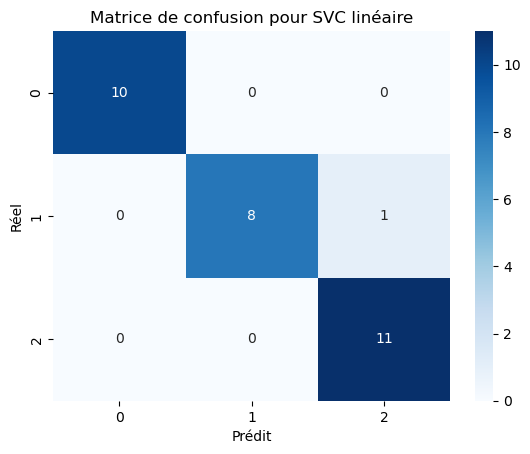

In [95]:
#Prediction pour le modele SVC lineaire
Y_pred=svm_linear.predict(X_test_scaled)
#Evaluation 
print("Accuracy:")
print(accuracy_score(Y_test,Y_pred))
print("Rapport de classification:")
print(classification_report(Y_test,Y_pred))
#Matrice de confusion pour SVC lineaire 
cm_linear=confusion_matrix(Y_test,Y_pred)
sns.heatmap(cm_linear,annot=True,fmt="d",cmap="Blues")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.title("Matrice de confusion pour SVC linéaire")


Accuracy: 0.9666666666666667
Rapport de classification:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.90      1.00      0.95         9
           2       1.00      0.91      0.95        11

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



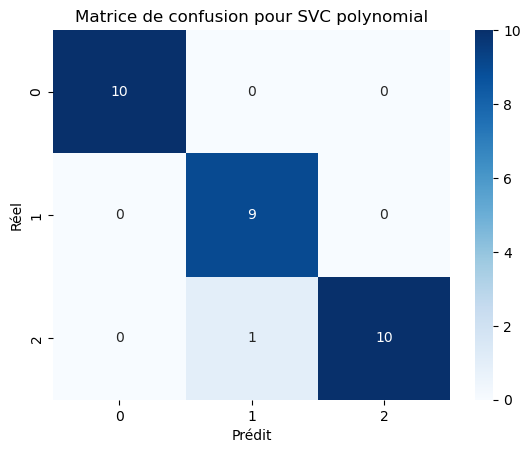

In [97]:
#Prediction pour le modele SVC polynomial 
Y_predict_poly=svm_poly.predict(X_test_scaled)
#Evaluation
print("Accuracy:",accuracy_score(Y_test,Y_predict_poly))
print("Rapport de classification:")
print(classification_report(Y_test,Y_predict_poly))
#Matrice de confusion pour SVC polynomiale 
cm_poly=confusion_matrix(Y_test,Y_predict_poly)
sns.heatmap(cm_poly,annot=True,fmt="d",cmap="Blues")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.title("Matrice de confusion pour SVC polynomial")
plt.show()


Accuracy: 1.0
Rapport de classification:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



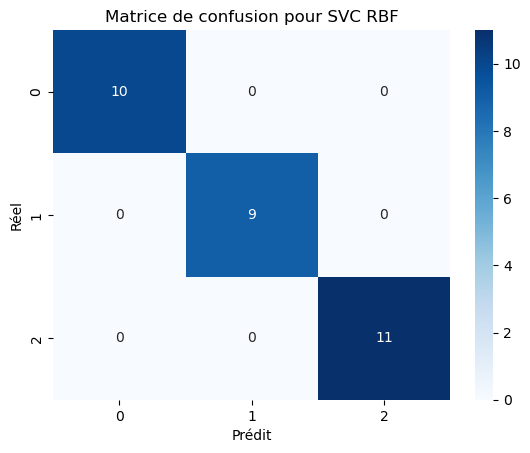

In [98]:
#Prediction pour le modele SVC rbf 
Y_predict_rbf=svm_rbf.predict(X_test_scaled)
#Evaluation
print("Accuracy:",accuracy_score(Y_test,Y_predict_rbf))
print("Rapport de classification:")
print(classification_report(Y_test,Y_predict_rbf))
#Matrice de confusion pour SVC rbf
cm_rbf=confusion_matrix(Y_test,Y_predict_rbf)
sns.heatmap(cm_rbf,annot=True,fmt="d",cmap="Blues")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.title("Matrice de confusion pour SVC RBF")
plt.show()


In [99]:
param_grid = [
    {'kernel': ['linear'], 'C': [0.1, 1, 10]},
    {'kernel': ['poly'], 'C': [0.1, 1, 10], 'degree': [2, 3, 4]},
    {'kernel': ['rbf'], 'C': [0.1, 1, 10], 'gamma': ['scale', 0.1, 0.01]}
]

grid = GridSearchCV(SVC(), param_grid, cv=5, scoring='accuracy')
grid.fit(X_train_scaled, Y_train)

print("Best parameters:", grid.best_params_)
print("Best CV score:", grid.best_score_)

y_pred_best = grid.predict(X_test_scaled)
print("Test accuracy:", accuracy_score(Y_test, y_pred_best))

Best parameters: {'C': 10, 'kernel': 'linear'}
Best CV score: 0.9583333333333334
Test accuracy: 0.9666666666666667
